# 🧠 5.1 MLP Classification Model & Hyperparameter Tuning

En este notebook se entrena un clasificador basado en **Redes Neuronales con Gated Pooling y MLP** para la predicción binaria sobre los embeddings generados.

---

## 📋 Descripción General
El objetivo de este script es realizar un entrenamiento sistemático probando diferentes arquitecturas de red para identificar cuál maximiza el rendimiento en la clasificación de secuencias proteicas, integrando información fisicoquímica mediante un mecanismo de *gating* guiado por AAontology.

## 🛠️ Funcionalidades Principales

1.  **Arquitectura del Modelo (`GatedMLPClassifier`):**
    * Integración de `AAontologyGatedPooler`: capa diferenciable que pondera los embeddings por residuo según perfiles fisicoquímicos precalculados (z-scored).
    * Cabeza MLP flexible con capas `Linear`, `GELU`, `LayerNorm` y `Dropout` (para regularización y estabilidad numérica).
    * Capa de salida con logit directo para optimización estable con `BCEWithLogitsLoss`.
2.  **Entrenamiento y Optimización:**
    * Uso del optimizador **AdamW** con `weight_decay` y scheduler `ReduceLROnPlateau` para ajuste dinámico del learning rate.
    * Implementación de **Early Stopping** (`patience=12`, `min_delta=1e-4`) para detener el entrenamiento cuando la pérdida de validación se estanca.
    * Manejo automático de desbalanceo de clases mediante `pos_weight` calculado sobre el dataset de entrenamiento.
3.  **Búsqueda de Hiperparámetros:**
    * Evaluación comparativa de 3 configuraciones (`Gated_MLP_Small`, `Medium`, `Large`) variando profundidad, anchura de capas ocultas y tasa de dropout.
4.  **Monitoreo y Registro:**
    * Cálculo y registro de métricas por época (Loss, Accuracy, ROC-AUC, PR-AUC, F1, MCC).
    * Generación de curvas de entrenamiento, tablas comparativas y persistencia automática del mejor checkpoint junto con su historial y métricas de validación.

## 📦 Importación de Librerías

In [1]:
import os
import json
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    matthews_corrcoef, confusion_matrix
)

import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.10.0+cu128
cuda available: True


## ⚙️ Configuración de Rutas e Hiperparámetros

In [2]:
# ========== PATHS ==========
DATA_DIR = Path("/kaggle/input/datasets/user/dataset-created")
OUT_DIR = Path("/kaggle/working/MLP_Results/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PT = DATA_DIR / "train_dataset.pt"
VAL_PT   = DATA_DIR / "val_dataset.pt"
AAONTOLOGY_PATH = "/kaggle/input/datasets/user/aantology/aa_ontology_zscored.pt"  # Tensor (20, 8) precomputado

# ========== HYPERPARAMETERS ==========
SEED        = 31
BATCH_SIZE  = 32
MAX_EPOCHS  = 100
PATIENCE    = 12       # Early stopping patience
MIN_DELTA   = 1e-4     # Minimum improvement for early stopping
L_MAX      = 100
INPUT_DIM   = 768      # Embedding dimension
N_AA        = 20
N_CAT       = 8           # 8 categorías AAontology

# ========== ARCHITECTURES ==========
ARCHITECTURES = [
    {
        "name": "Gated_MLP_Small",
        "hidden_dims": [256, 128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_MLP_Medium",
        "hidden_dims": [512, 256, 128],
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
    },
    {
        "name": "Gated_MLP_Large",
        "hidden_dims": [1024, 512, 256, 128],
        "dropout": 0.4,
        "lr": 5e-4,
        "weight_decay": 1e-4,
    },
]

## 🖥️ Inicialización de Hardware & Reproducibilidad

In [3]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE: {DEVICE}")

DEVICE: cuda


## 🧬 Carga del Tensor Fisicoquímico (AAontology)

In [4]:
# Carga el tensor (20, 8) precomputado con z-scores por categoría
if Path(AAONTOLOGY_PATH).exists():
    aa_data = torch.load(AAONTOLOGY_PATH, map_location="cpu", weights_only=True)
    AAONTOLOGY_ZSCORED = aa_data["tensor"]  # (20, 8)
    AA_ORDER = aa_data["amino_acids"]        # list de 20 AA
    USED_CATEGORIES = aa_data["categories"]    # 8 categorías
else:
    raise FileNotFoundError(f"No se encontró {AAONTOLOGY_PATH}. Genera el tensor primero.")

# Mapeo AA → índice para lookup rápido
AA_TO_IDX = {aa: i for i, aa in enumerate(AA_ORDER)}

print(f"AAontology tensor: {AAONTOLOGY_ZSCORED.shape}")
print(f"Categorías: {USED_CATEGORIES}")

AAontology tensor: torch.Size([21, 8])
Categorías: ['ASA/Volume', 'Composition', 'Conformation', 'Energy', 'Polarity', 'Shape', 'Structure-Activity', 'Others']


## 📊 Clase `AMPDataset` (PyTorch Dataset Custom)

In [5]:
class AMPDataset(Dataset):
    """
    Estructura por muestra:
        X:   torch.FloatTensor (L_max, 768)  — ProtFlash embeddings
        G:   torch.FloatTensor (L_max, 8)    — AAontology features
        M:   torch.FloatTensor (L_max,)      — binary mask
        seq: str                             — AA sequence (for AAontology)
        y:   torch.FloatTensor (1,)          — label
    """
    def __init__(self, X, G, M, sequences, labels):
        self.X = torch.from_numpy(X).float()          # (N, L_max, 768)
        self.G = torch.from_numpy(G).float()          # (N, L_max, 8)
        assert self.G.shape[-1] == 8, f"Se esperaban 8 categorías de ontología, pero G tiene shape {self.G.shape}"
        self.M = torch.from_numpy(M).float()          # (N, L_max)
        self.sequences = list(sequences)
        self.y = torch.from_numpy(labels).float().unsqueeze(1)  # (N, 1)

        assert len(self.X) == len(self.G) == len(self.M) == len(self.seqs) == len(self.y), \
            "Las longitudes de X, G, M, seqs y y no coinciden."

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],           # (L_max, 768)
            "G": self.G[idx],           # (L_max, 8)
            "M": self.M[idx],           # (L_max,)
            "seq": self.sequences[idx],      # str (Ej: "MKLL...")
            "y": self.y[idx]            # (1,)
        }

## 📂 Carga de Datasets Serializados (`.pt`)

In [6]:
def load_pt_dataset(pt_path):
    pt_path = Path(pt_path)
    if not pt_path.exists(): raise FileNotFoundError
    return torch.load(pt_path, map_location="cpu", weights_only=False)

## ✅ Carga y Validación Rápida

In [7]:
print("Loading datasets:")
train_ds = load_pt_dataset(TRAIN_PT)
val_ds   = load_pt_dataset(VAL_PT)

print(f"\n🔍 Test __len__:")
print(f"   train_ds: {len(train_ds)} muestras")
print(f"   val_ds  : {len(val_ds)} muestras")

print(f"\n🔍 Test __getitem__[0]:")
sample = train_ds[0]
keys = ['X', 'G', 'M', 'seq', 'y']

for k, v in zip(keys, sample):
    if isinstance(v, torch.Tensor):
        print(f"   {k}: {tuple(v.shape)} {v.dtype}")
    else:
        print(f"   {k}: {type(v).__name__} = '{str(v)[:50]}'")

Loading datasets:

🔍 Test __len__:
   train_ds: 13826 muestras
   val_ds  : 3614 muestras

🔍 Test __getitem__[0]:
   X: str = 'X'
   G: str = 'G'
   M: str = 'M'
   seq: str = 'seq'
   y: str = 'y'


## 🧩 Función `collate_fn` para DataLoaders

In [8]:
def collate_fn(batch):
    """
    Collate function construye dinámicamente los perfiles de AAontology (B, L, 8)
    a partir de las secuencias.
    """
    if isinstance(batch[0], dict):
        # 1. Extraer tensores base
        X = torch.stack([item['X'] for item in batch])   # (B, L, 768)
        M = torch.stack([item['M'] for item in batch])   # (B, L)
        y = torch.stack([item['y'] for item in batch])   # (B, 1)
        seqs = [item['seq'] for item in batch]           # List[str]
        
        # 2. Contruir perfiles de ontología
        B, L, _ = X.shape
        # Inicializamos el tensor de ontología en ceros
        ont_profiles = torch.zeros(B, L, 8, dtype=X.dtype, device=X.device)
        
        for i, seq in enumerate(seqs):
            for j, aa in enumerate(seq[:L]):
                if aa in AA_TO_IDX:
                    # Asignamos las 8 categorías z-scored para este aminoácido
                    ont_profiles[i, j] = AAONTOLOGY_ZSCORED[AA_TO_IDX[aa]]
        return X, ont_profiles, M, seqs, y
    else:
        raise TypeError("Batch fallido: se esperaba un diccionario por muestra.")

## 🔄 Creación de DataLoaders

In [9]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"\n✅ Batches: train={len(train_loader)}, val={len(val_loader)}")

X_b, G_b, M_b, seq_b, y_b = next(iter(train_loader)) # <-- Agregamos G_b
print(f"   ✅ X_b: {tuple(X_b.shape)} | G_b: {tuple(G_b.shape)} | seq_b: {len(seq_b)}")


✅ Batches: train=433, val=113
   ✅ X_b: (32, 100, 768) | G_b: (32, 100, 8) | seq_b: 32


## 🔑 Mecanismo `AAontologyGatedPooler`

In [10]:
class AAontologyGatedPooler(nn.Module):
    """
    Gated Pooling que combina el contexto de ProtFlash (X) 
    con el prior bioquímico de AAontology (P).
    """
    def __init__(self, input_dim: int = 768, n_categories: int = 8):
        super().__init__()
        self.n_categories = n_categories
        
        # Proyectamos la ontología (8 -> 64)
        self.ont_proj = nn.Linear(n_categories, 64) 
        
        # Red de gating CONSCIENTE DEL CONTEXTO (768 + 64 = 832)
        self.gating_mlp = nn.Sequential(
            nn.Linear(input_dim + 64, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )
        
        self.proj = nn.Linear(input_dim, input_dim)

    def forward(self, X: torch.Tensor, G: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        """
        X: (B, L, 768) - ProtFlash
        G: (B, L, 8)   - AAontology precalculada (viene del Dataset)
        M: (B, L)      - Mask
        """
        # 1. Proyectar ontología (B, L, 64) - ¡Todo en GPU, sin bucles Python!
        ont_proj = self.ont_proj(G) 
        
        # 2. CONCATENAR Contexto + Ontología (B, L, 832)
        combined_features = torch.cat([X, ont_proj], dim=-1)
        
        # 3. Calcular gates (B, L, 1)
        gates = self.gating_mlp(combined_features) * M.unsqueeze(-1)
        
        # 4. Agregación ponderada
        weighted = gates * self.proj(X) * M.unsqueeze(-1)
        return weighted.sum(dim=1) / (M.sum(dim=1, keepdim=True) + 1e-8)

## 🤖 Modelo `GatedMLPClassifier` y Verificación

In [11]:
class GatedMLPClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float = 0.3, n_categories: int = 8):
        super().__init__()
        
        # 1. Pooler Biofísico
        self.pooler = AAontologyGatedPooler(input_dim=input_dim, n_categories=n_categories)
        
        # 2. MLP Body
        # La entrada será: Local Gated (input_dim) + Global Context (input_dim) = input_dim * 2
        layers = []
        in_features = input_dim * 2 # 768 + 768 = 1536
        
        for out_features in hidden_dims:
            layers.append(nn.Linear(in_features, out_features))
            layers.append(nn.BatchNorm1d(out_features))
            layers.append(nn.GELU()) # GELU > ReLU
            layers.append(nn.Dropout(dropout))
            in_features = out_features
            
        self.mlp_body = nn.Sequential(*layers)
        self.classifier = nn.Linear(in_features, 1)

    def forward(self, X: torch.Tensor, ont_profiles: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        """
        X: (B, L, 768) - ProtFlash embeddings
        ont_profiles: (B, L, 8) - AAontology per-residue features (lo que antes era 'G' en el Dataset)
        M: (B, L) - Binary mask
        """
        # A. Extrae resumen local guiado por Física + Contexto 
        E_local = self.pooler(X, ont_profiles, M)  # Shape: (B, 768)
        
        # B. Extrae resumen Global de ProtFlash (Masked Mean Pooling de X)
        mask_expanded = M.unsqueeze(-1)
        E_global = (X * mask_expanded).sum(dim=1) / (M.sum(dim=1, keepdim=True) + 1e-8) # Shape: (B, 768)
        
        # C. Concatenación [Biología Física Local + Semántica Global] y Clasificación
        combined_features = torch.cat([E_local, E_global], dim=1) # Shape: (B, 1536)
        
        x = self.mlp_body(combined_features)
        return self.classifier(x)
    
    def get_gates(self, X: torch.Tensor, ont_profiles: torch.Tensor, M: torch.Tensor) -> torch.Tensor:
        """Extrae los valores de gate para explicabilidad (XAI / SHAP / IG)."""
        # Replicamos la lógica interna del pooler para obtener los gates crudos sin hacer el pooling final
        ont_proj = self.pooler.ont_proj(ont_profiles)             # (B, L, 64)
        combined_features = torch.cat([X, ont_proj], dim=-1)      # (B, L, 832)
        gates = self.pooler.gating_mlp(combined_features)         # (B, L, 1)
        
        # Anulamos el padding y devolvemos (B, L)
        return gates.squeeze(-1) * M 

def build_gated_model(config: Dict, input_dim: int) -> nn.Module:
    return GatedMLPClassifier(input_dim, config["hidden_dims"], config["dropout"])


# ========== SANITY CHECK ==========
_test_model = build_gated_model(ARCHITECTURES[0], INPUT_DIM)

# Generamos datos dummy con las nuevas dimensiones
_test_X = torch.randn(2, L_MAX, INPUT_DIM)
_test_ont = torch.randn(2, L_MAX, 8)  # (B, L, 8)
_test_M = torch.ones(2, L_MAX)
_test_M[0, 50:] = 0  # simular padding

with torch.no_grad():
    _test_out = _test_model(_test_X, _test_ont, _test_M)
    _test_gates = _test_model.get_gates(_test_X, _test_ont, _test_M)
    
_n = sum(p.numel() for p in _test_model.parameters())
print(f"Sanity check ({ARCHITECTURES[0]['name']}): params={_n:,}, output shape={_test_out.shape}, gates shape={_test_gates.shape}")

del _test_model, _test_X, _test_ont, _test_M, _test_out, _test_gates

Sanity check (Gated_MLP_Small): params=1,125,442, output shape=torch.Size([2, 1]), gates shape=torch.Size([2, 100])


## 📐 Helper: `sigmoid_np`

In [12]:
def sigmoid_np(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

## 🔮 Inferencia: `predict_proba`

In [13]:
@torch.no_grad()
def predict_proba(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()
    logits_list, y_list = [], []
    for Xb, Gb, Mb, seqs, yb in loader:
        logits = model(Xb.to(device), Gb.to(device), Mb.to(device))
        logits_list.append(logits.cpu().numpy().reshape(-1))
        y_list.append(yb.cpu().numpy().reshape(-1))
    return sigmoid_np(np.concatenate(logits_list)), np.concatenate(y_list)

## 📏 Cálculo de Métricas de Clasificación

In [14]:
def compute_metrics(y_true, y_prob):
    y_pred = (y_prob >= 0.5).astype(int)
    y_true = y_true.astype(int)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)) if len(np.unique(y_true)) > 1 else 0.0,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
    }

In [15]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha; self.gamma = gamma
        
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt)**self.gamma * bce).mean()

## 🔄 Loops de Entrenamiento

In [16]:
def train_model(config, input_dim, train_loader, val_loader, device, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    seed_everything(SEED)
    model = build_gated_model(config, input_dim).to(device)
    criterion = FocalLoss(alpha=0.75, gamma=2.0).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    history = {"epoch": [], "train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_mcc": []}
    best_val_loss = float("inf")
    best_state = None; best_epoch = 0; no_improve = 0

    for epoch in range(1, max_epochs + 1):
        # TRAIN
        model.train()
        train_loss, n = 0.0, 0
        for Xb, Gb, Mb, seqs, yb in train_loader:
            Xb, Gb, Mb, yb = Xb.to(device), Gb.to(device), Mb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb, Gb, Mb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item() * Xb.size(0)
            n += Xb.size(0)
        train_loss /= n

        # VAL
        model.eval()
        val_loss, n = 0.0, 0
        with torch.no_grad():
            for Xb, Gb, Mb, seqs, yb in val_loader:
                Xb, Gb, Mb, yb = Xb.to(device), Gb.to(device), Mb.to(device), yb.to(device)
                loss = criterion(model(Xb, Gb, Mb), yb)
                val_loss += loss.item() * Xb.size(0)
                n += Xb.size(0)
        val_loss /= n
        
        scheduler.step(val_loss)
        
        # Guardar métricas
        train_p, train_y = predict_proba(model, train_loader, device)
        val_p, val_y = predict_proba(model, val_loader, device)
        v_met = compute_metrics(val_y, val_p)
        
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_acc"].append(compute_metrics(train_y, train_p)["accuracy"]); history["val_acc"].append(v_met["accuracy"])
        history["val_mcc"].append(v_met["mcc"])

        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k,v in model.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1

        print(f"E{epoch:02d} | TL: {train_loss:.4f} | VL: {val_loss:.4f} | Val MCC: {v_met['mcc']:.4f} | B_ep: {best_epoch}")
        if no_improve >= patience: break

    model.load_state_dict(best_state)
    return {"model": model, "history": history, "best_epoch": best_epoch, "best_val_loss": best_val_loss}

## 🔬 Ejecución Secuencial de Arquitecturas

In [17]:
all_results = []
for idx, config in enumerate(ARCHITECTURES):
    print(f"\n--- Entrenando {config['name']} ---")
    start_time = time.time()
    res = train_model(config, INPUT_DIM, train_loader, val_loader, DEVICE)
    training_time = time.time() - start_time
    val_proba, val_y = predict_proba(res["model"], val_loader, DEVICE)
    v_metrics = compute_metrics(val_y, val_proba)
    
    n_params = sum(p.numel() for p in res["model"].parameters())
    
    ckpt_path = OUT_DIR / f"checkpoint_{config['name']}.pth"
    torch.save({"model_name": config["name"], "state_dict": res["model"].state_dict(), "config": config, "input_dim": INPUT_DIM}, ckpt_path)
    
    all_results.append({
        "name": config["name"],
        "n_params": n_params,
        "best_epoch": res["best_epoch"],
        "best_val_loss": res["best_val_loss"],
        "val_accuracy": v_metrics["accuracy"],
        "val_f1": v_metrics["f1"],
        "val_mcc": v_metrics["mcc"],
        "val_roc_auc": v_metrics["roc_auc"],
        "val_pr_auc": v_metrics["pr_auc"],
        "training_time_sec": training_time,
        "config": config,
        "model": res["model"],
        "history": res["history"]
    })

    print(f"\n  ✅ {config['name']}: params={n_params:,} | "
          f"best_epoch={res['best_epoch']} | val_loss={res['best_val_loss']:.4f}")
    print(f"     val_acc={v_metrics['accuracy']:.4f} | val_f1={v_metrics['f1']:.4f} | "
          f"val_mcc={v_metrics['mcc']:.4f} | val_auc={v_metrics['roc_auc']:.4f}")
    print(f"     Saved: {ckpt_path}")

print("\n" + "=" * 90)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 90)



--- Entrenando Gated_MLP_Small ---
E01 | TL: 0.0626 | VL: 0.0542 | Val MCC: 0.7697 | B_ep: 1
E02 | TL: 0.0539 | VL: 0.0545 | Val MCC: 0.7605 | B_ep: 1
E03 | TL: 0.0497 | VL: 0.0504 | Val MCC: 0.7916 | B_ep: 3
E04 | TL: 0.0462 | VL: 0.0517 | Val MCC: 0.7866 | B_ep: 3
E05 | TL: 0.0439 | VL: 0.0530 | Val MCC: 0.7717 | B_ep: 3
E06 | TL: 0.0428 | VL: 0.0532 | Val MCC: 0.7667 | B_ep: 3
E07 | TL: 0.0415 | VL: 0.0530 | Val MCC: 0.7941 | B_ep: 3
E08 | TL: 0.0382 | VL: 0.0496 | Val MCC: 0.8014 | B_ep: 8
E09 | TL: 0.0384 | VL: 0.0560 | Val MCC: 0.7862 | B_ep: 8
E10 | TL: 0.0369 | VL: 0.0562 | Val MCC: 0.7896 | B_ep: 8
E11 | TL: 0.0351 | VL: 0.0511 | Val MCC: 0.7988 | B_ep: 8
E12 | TL: 0.0346 | VL: 0.0517 | Val MCC: 0.8082 | B_ep: 8
E13 | TL: 0.0314 | VL: 0.0513 | Val MCC: 0.8084 | B_ep: 8
E14 | TL: 0.0305 | VL: 0.0540 | Val MCC: 0.8058 | B_ep: 8
E15 | TL: 0.0256 | VL: 0.0567 | Val MCC: 0.8063 | B_ep: 8
E16 | TL: 0.0228 | VL: 0.0646 | Val MCC: 0.7970 | B_ep: 8
E17 | TL: 0.0213 | VL: 0.0621 | Val 

## 📊 Tabla Resumen y Ranking de Modelos

In [18]:
summary_rows = []
for r in all_results:
    summary_rows.append({
        "Model": r["name"],
        "Params": r["n_params"],
        "Best Epoch": r["best_epoch"],
        "Val Loss": r["best_val_loss"],
        "Val Acc": r["val_accuracy"],
        "Val F1": r["val_f1"],
        "Val MCC": r["val_mcc"],
        "Val ROC-AUC": r["val_roc_auc"],
        "Val PR-AUC": r["val_pr_auc"],
        "Time (s)": round(r["training_time_sec"], 1),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Val MCC", ascending=False).reset_index(drop=True)
print("\n=== RANKING DE ARQUITECTURAS ===")
print(summary_df.to_string())

summary_df.to_csv(OUT_DIR / "architecture_comparison.csv", index=False)
print(f"\nSaved")

best_name = summary_df.iloc[0]["Model"]
best_result = next(r for r in all_results if r["name"] == best_name)
print(f"\n🏆 Best model: {best_name}")


=== RANKING DE ARQUITECTURAS ===
              Model   Params  Best Epoch  Val Loss   Val Acc    Val F1   Val MCC  Val ROC-AUC  Val PR-AUC  Time (s)
0  Gated_MLP_Medium  1651266           6  0.048773  0.903431  0.886208  0.807500     0.956310    0.960380     342.5
1   Gated_MLP_Large  2965058           7  0.048049  0.902048  0.886611  0.802964     0.959364    0.962103     358.7
2   Gated_MLP_Small  1125442           8  0.049608  0.900387  0.882430  0.801444     0.957358    0.960370     383.5

Saved

🏆 Best model: Gated_MLP_Medium


## 📈 Visualización: Curvas de Entrenamiento Individuales

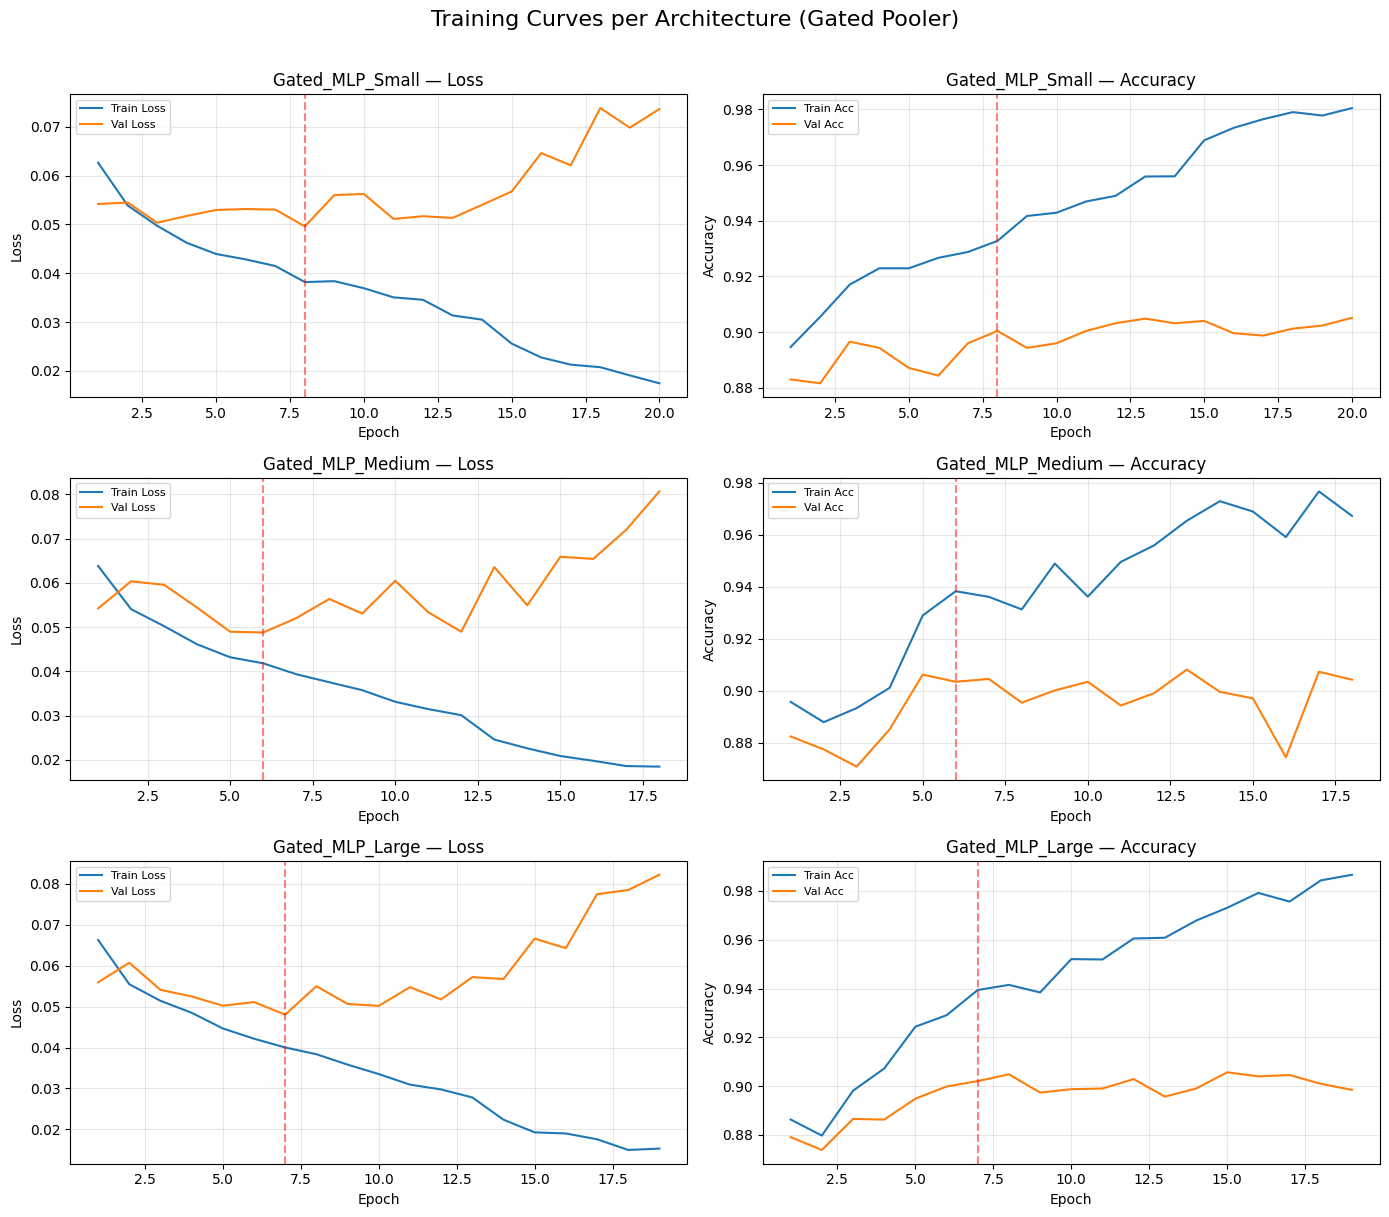

Saved: /kaggle/working/MLP_Results/training_curves_individual.png


In [19]:
n_models = len(all_results)
fig, axes = plt.subplots(n_models, 2, figsize=(14, 4 * n_models), squeeze=False)

for idx, r in enumerate(all_results):
    h = r["history"]
    epochs = h["epoch"]

    ax_loss = axes[idx, 0]
    ax_loss.plot(epochs, h["train_loss"], label="Train Loss", linewidth=1.5)
    ax_loss.plot(epochs, h["val_loss"], label="Val Loss", linewidth=1.5)
    ax_loss.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5)
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.set_title(f"{r['name']} — Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.grid(True, alpha=0.3)

    ax_acc = axes[idx, 1]
    ax_acc.plot(epochs, h["train_acc"], label="Train Acc", linewidth=1.5)
    ax_acc.plot(epochs, h["val_acc"], label="Val Acc", linewidth=1.5)
    ax_acc.axvline(r["best_epoch"], color="red", linestyle="--", alpha=0.5)
    ax_acc.set_xlabel("Epoch")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.set_title(f"{r['name']} — Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(True, alpha=0.3)

fig.suptitle("Training Curves per Architecture (Gated Pooler)", fontsize=16, y=1.01)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_individual.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_individual.png'}")

## 📈 Visualización: Comparación Directa entre Modelos

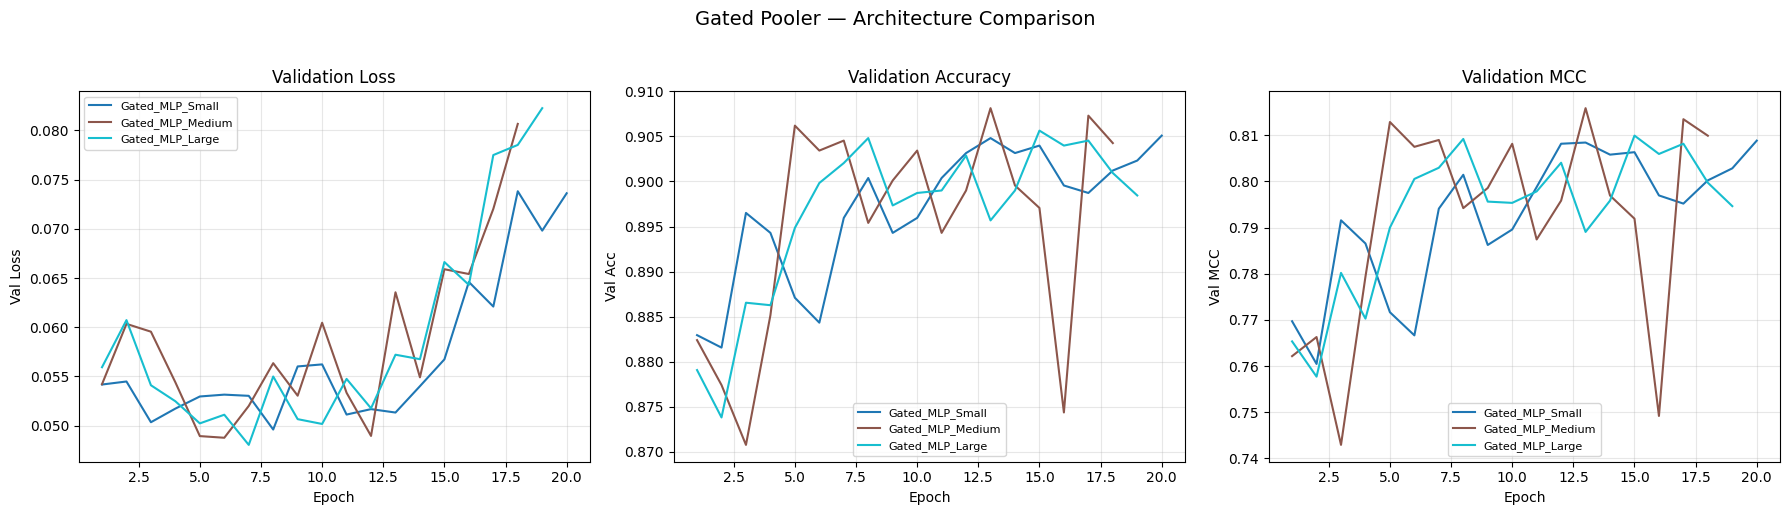

Saved: /kaggle/working/MLP_Results/training_curves_comparison.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for idx, r in enumerate(all_results):
    h = r["history"]
    axes[0].plot(h["epoch"], h["val_loss"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[1].plot(h["epoch"], h["val_acc"], label=r["name"], color=colors[idx], linewidth=1.5)
    axes[2].plot(h["epoch"], h["val_mcc"], label=r["name"], color=colors[idx], linewidth=1.5)

# Eje 0: Loss
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Loss"); axes[0].set_title("Validation Loss")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Eje 1: Accuracy
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Acc"); axes[1].set_title("Validation Accuracy")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# ✅ Eje 2: MCC 
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Val MCC"); axes[2].set_title("Validation MCC")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

fig.suptitle("Gated Pooler — Architecture Comparison", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(OUT_DIR / "training_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR / 'training_curves_comparison.png'}")

## 📊 Visualización: Gráfico de Barras Comparativo

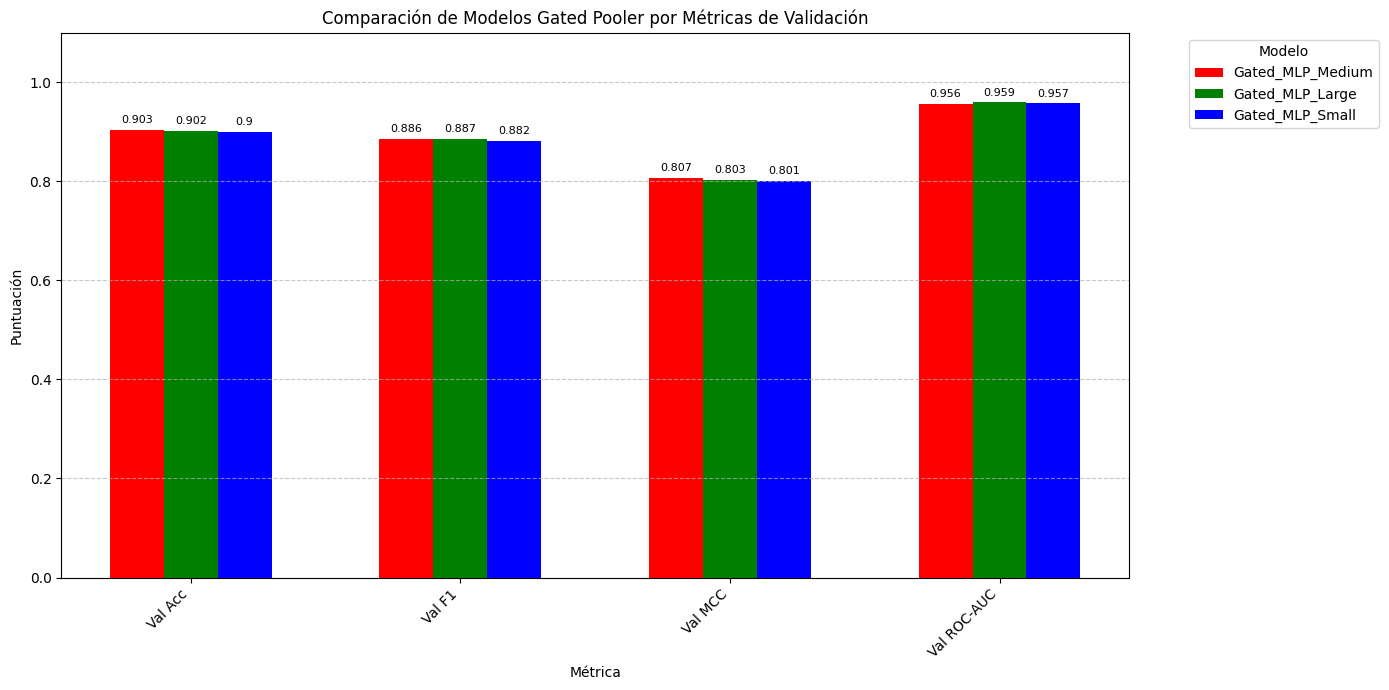

Saved: /kaggle/working/MLP_Results/model_metrics_comparison_bar_chart.png


In [21]:
metric_cols = ["Val Acc", "Val F1", "Val MCC", "Val ROC-AUC"]
model_names = summary_df['Model'].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
bar_width = 0.2
index = np.arange(len(metric_cols))
custom_colors = ['red', 'green', 'blue']

for i, model_name in enumerate(model_names):
    model_scores = summary_df[summary_df['Model'] == model_name][metric_cols].values.flatten()
    bars = ax.bar(index + i * bar_width, model_scores, bar_width, label=model_name, color=custom_colors[i % len(custom_colors)])
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.01, round(yval, 3),
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Métrica')
ax.set_ylabel('Puntuación')
ax.set_title('Comparación de Modelos Gated Pooler por Métricas de Validación')
ax.set_xticks(index + bar_width * (len(model_names) - 1) / 2)
ax.set_xticklabels(metric_cols, rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.legend(title='Modelo', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plot_path = OUT_DIR / "model_metrics_comparison_bar_chart.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved: {plot_path}")

## 💾 Guardado del Mejor Modelo y Artefactos

In [22]:
best_model = best_result["model"]
best_config = best_result["config"]

val_proba_final, val_y_final = predict_proba(best_model, val_loader, DEVICE)
val_metrics_final = compute_metrics(val_y_final, val_proba_final)

final_ckpt_path = OUT_DIR / "best_model_final.pth"
final_checkpoint = {
    "model_name": best_config["name"],
    "state_dict": best_model.state_dict(),
    "config": best_config,
    "input_dim": INPUT_DIM,
    "n_params": best_result["n_params"],
    "best_epoch": best_result["best_epoch"],
    "best_val_loss": best_result["best_val_loss"],
    "training_time_sec": best_result["training_time_sec"],
    "val_metrics": val_metrics_final,
    "history": best_result["history"],
    "hyperparameters": {
        "seed": SEED,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "min_delta": MIN_DELTA,
        "lr": best_config["lr"],
        "weight_decay": best_config["weight_decay"],
    },
}
torch.save(final_checkpoint, final_ckpt_path)

history_df = pd.DataFrame(best_result["history"])
history_path = OUT_DIR / "best_model_training_log.csv"
history_df.to_csv(history_path, index=False)

metrics_path = OUT_DIR / "best_model_val_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(val_metrics_final, f, indent=2)

print(f"\n🏆 Best model: {best_config['name']}")
print(f"   Parameters: {best_result['n_params']:,}")
print(f"   Best epoch: {best_result['best_epoch']}")
print(f"   Val loss:   {best_result['best_val_loss']:.6f}")
print(f"\nSaved:")
print(f"  Checkpoint:    {final_ckpt_path}")
print(f"  Training log:  {history_path}")
print(f"  Val metrics:   {metrics_path}")


🏆 Best model: Gated_MLP_Medium
   Parameters: 1,651,266
   Best epoch: 6
   Val loss:   0.048773

Saved:
  Checkpoint:    /kaggle/working/MLP_Results/best_model_final.pth
  Training log:  /kaggle/working/MLP_Results/best_model_training_log.csv
  Val metrics:   /kaggle/working/MLP_Results/best_model_val_metrics.json


# 🏆 Conclusión: Mejor Arquitectura Seleccionada

Tras completar el proceso de experimentación y comparación de arquitecturas, se concluye que la configuración **Gated_MLP_Medium** ofrece el mejor rendimiento general.

### 📊 Resultados Destacados
* **Máxima Discriminación:** Logró el mayor **MCC de validación (0.8075)** y **Accuracy (0.9034)**, demostrando una capacidad superior para equilibrar sensibilidad y especificidad en la clasificación de péptidos.
* **Convergencia Estable:** Gracias al *Gated Pooling* guiado por AAontology y un *Dropout* del 0.4, el modelo convergió de forma robusta en la **época 6**, manteniendo una brecha mínima entre entrenamiento y validación.
* **Eficiencia Operativa:** A pesar de contar con ~1.65M parámetros, el procesamiento por lotes en GPU mantiene el tiempo de inferencia en el rango de milisegundos, haciéndolo ideal para cribado de alto rendimiento.

### 📦 Estado Final & Despliegue
El modelo ganador ha sido exportado y serializado junto con sus metadatos de trazabilidad:
* `best_model_final.pth` → Checkpoint completo (state_dict, config, métricas, historia)
* `best_model_training_log.csv` → Evolución por época (loss, acc, LR, ROC-AUC)
* `best_model_val_metrics.json` → Métricas de validación finales en formato estructurado